In [1]:
%reload_ext autoreload
%autoreload 2
from graph_factory import GraphFactory, add_graph_plot, calc_graph_metrics
import networkx as nx
import numpy as np
import cvxpy as cp
import seaborn as sns
from scipy.linalg import eigh
import matplotlib.pyplot as plt
import scipy.linalg as sla

In [2]:
global_seed = 0
global_rng = np.random.default_rng(global_seed)

## Graph Examples

In [3]:
# Parameters
num_nodes = 20
b = 3

In [4]:
%%capture
gf = GraphFactory(num_nodes, b, global_seed)
fig, ax = plt.subplots(2,2,figsize=(10,8))

In [5]:
target_pi = global_rng.dirichlet(np.full(num_nodes, 10))

In [6]:
%%capture
graph_args = {
    'ws_k': 4,
    'ws_p': 0.1,
    'MH_target_pi':target_pi
}
G,W,sampling_subset = gf.create_graph("watts-strogatz", "MH_gen", **graph_args)
B = global_rng.choice(sampling_subset, size=b, replace=False)
H = np.array(list(set(np.arange(num_nodes)) - set(B)))
assert nx.is_connected(G.subgraph(H))

add_graph_plot(G,B,ax[0][0])
ax[0][0].set_title("Watts-Strogatz")

In [7]:
%%capture
graph_args = {
    'MH_target_pi':target_pi
}
G, W, sampling_subset = gf.create_graph("complete", "MH_gen", **graph_args)
B = global_rng.choice(sampling_subset, size=b, replace=False)
H = np.array(list(set(np.arange(num_nodes)) - set(B)))
assert nx.is_connected(G.subgraph(H))

add_graph_plot(G,B,ax[0][1])
ax[0][1].set_title("Complete")

In [8]:
%%capture
graph_args = {
    'er_p': min(1.0, 3.0 * np.log(num_nodes) / num_nodes),
    'MH_target_pi':target_pi
}
G, W, sampling_subset = gf.create_graph("erdos-renyi", "MH", **graph_args)
B = global_rng.choice(sampling_subset, size=b, replace=False)
H = np.array(list(set(np.arange(num_nodes)) - set(B)))
assert nx.is_connected(G.subgraph(H))

add_graph_plot(G,B,ax[1][0])
ax[1][0].set_title("Erdos-Renyi")

In [9]:
%%capture
graph_args = {
    'geom_radius': 0.4,
    'MH_target_pi':target_pi
}
G, W, sampling_subset = gf.create_graph("geometric", "MH", **graph_args)
B = global_rng.choice(sampling_subset, size=b, replace=False)
H = np.array(list(set(np.arange(num_nodes)) - set(B)))
assert nx.is_connected(G.subgraph(H))

add_graph_plot(G,B,ax[1][1])
ax[1][1].set_title("Geometric")

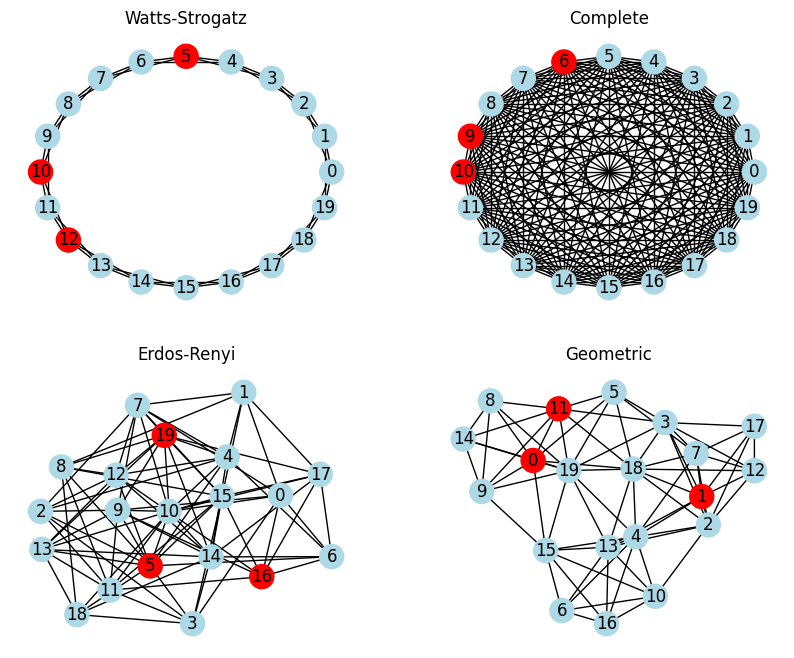

In [10]:
display(fig)

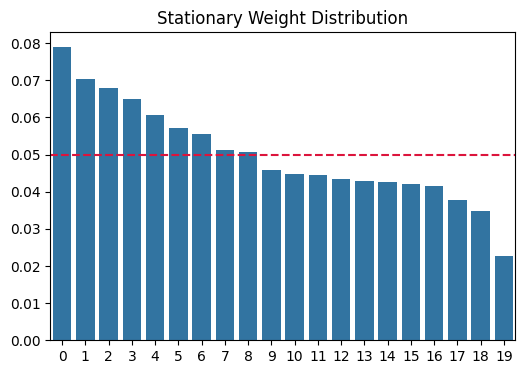

In [11]:
fig, ax = plt.subplots(1,1, figsize=(6,4))
sns.barplot(x=np.arange(num_nodes), y=np.sort(target_pi)[::-1], ax=ax)
ax.axhline(1/num_nodes, ls="--", color="crimson")
ax.set_title("Stationary Weight Distribution")
plt.show()